# Классификация Oxford Pets

Обучим сеть для классификации исходного датасета [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Загрузите датасет с Kaggle.

Для визуализации изображений используйте функцию:

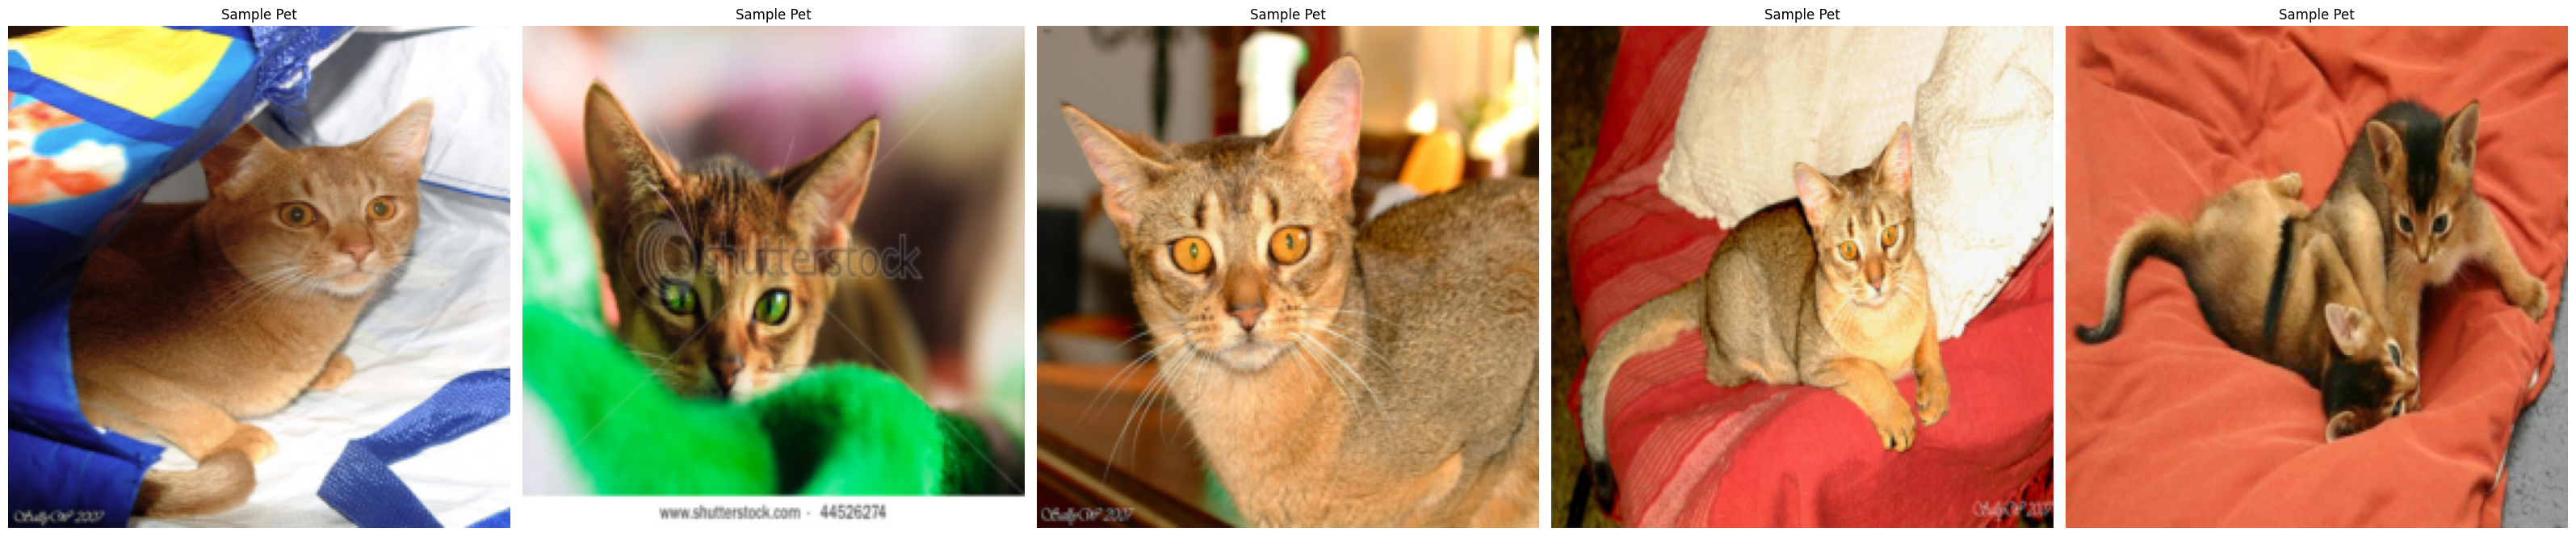

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

def display_images(l, titles=None, fontsize=12):
    n = len(l)
    fig, ax = plt.subplots(1, n)
    for i, im in enumerate(l):
        if torch.is_tensor(im):
            im = im.permute(1, 2, 0).cpu().numpy()
            im = im * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            im = np.clip(im, 0, 1)
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i], fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches() * n)
    plt.tight_layout()
    plt.show()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.OxfordIIITPet(root='.', split='trainval', download=True, transform=transform)
test_data = datasets.OxfordIIITPet(root='.', split='test', download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

raw_images = [train_data[i][0] for i in range(5)]
display_images(raw_images, titles=["Sample Pet"]*5)

Сравнение моделей

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_model(name):
    if name == 'vgg16':
        m = models.vgg16(weights='DEFAULT')
        for param in m.parameters(): param.requires_grad = False
        m.classifier[6] = nn.Linear(4096, 37)
    elif name == 'vgg19':
        m = models.vgg19(weights='DEFAULT')
        for param in m.parameters(): param.requires_grad = False
        m.classifier[6] = nn.Linear(4096, 37)
    elif name == 'resnet18':
        m = models.resnet18(weights='DEFAULT')
        for param in m.parameters(): param.requires_grad = False
        m.fc = nn.Linear(m.fc.in_features, 37)
    return m.to(device)

model_names = ['vgg16', 'vgg19', 'resnet18']
results = {}

for name in model_names:
    print(f"--- Обучение {name} ---")
    model = get_model(name)
    optimizer = optim.Adam(model.parameters() if name == 'resnet18' else model.classifier.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for i, (imgs, lbls) in enumerate(train_loader):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        if i > 50: break 

    model.eval()
    correct = 0
    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(test_loader):
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            correct += (outputs.argmax(1) == lbls).sum().item()
            if i > 20: break

    acc = correct / (21 * 32)
    results[name] = acc
    print(f"Точность {name}: {acc:.4f}")

best_model_name = max(results, key=results.get)
print(f"Лучшая модель: {best_model_name}")

--- Обучение vgg16 ---
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:11<00:00, 46.5MB/s] 
100%|██████████| 548M/548M [00:09<00:00, 61.7MB/s] 


Точность vgg19: 0.8140
--- Обучение resnet18 ---
Точность resnet18: 0.4241
Лучшая модель: vgg19


Дообучаем лучшую модель

Точность породы: 88.91%
Top-3: 98.61% | Top-5: 99.48%
Бинарная точность (Кот/Собака): 94.25%


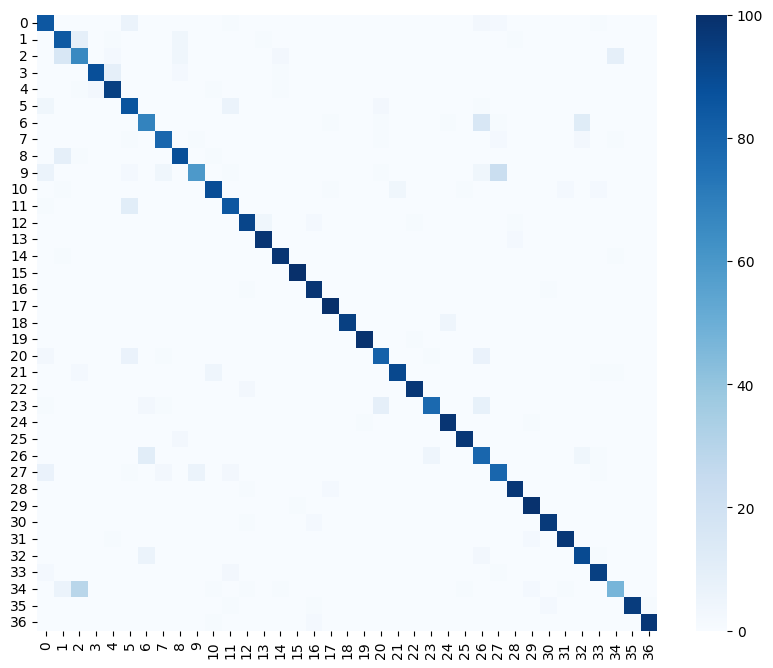

In [ ]:

best_model = get_model(best_model_name)
optimizer = optim.Adam(best_model.parameters(), lr=0.001)
for epoch in range(3):
    best_model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(best_model(imgs), lbls)
        loss.backward()
        optimizer.step()

best_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = best_model(imgs)
        all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

top3, top5 = 0, 0
for i in range(len(all_labels)):
    sorted_idx = np.argsort(all_probs[i])
    if all_labels[i] in sorted_idx[-3:]: top3 += 1
    if all_labels[i] in sorted_idx[-5:]: top5 += 1

print(f"Точность породы: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print(f"Top-3: {top3/len(all_labels)*100:.2f}% | Top-5: {top5/len(all_labels)*100:.2f}%")

bin_preds = [1 if p < 12 else 0 for p in all_preds]
bin_labels = [1 if l < 12 else 0 for l in all_labels]
print(f"Бинарная точность (Кот/Собака): {accuracy_score(bin_labels, bin_preds)*100:.2f}%")

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=False, cmap='Blues')
plt.show()

Определим на какие части смотрит сеть при определении класса с помощью GradCAM

Выбран слой для визуализации: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


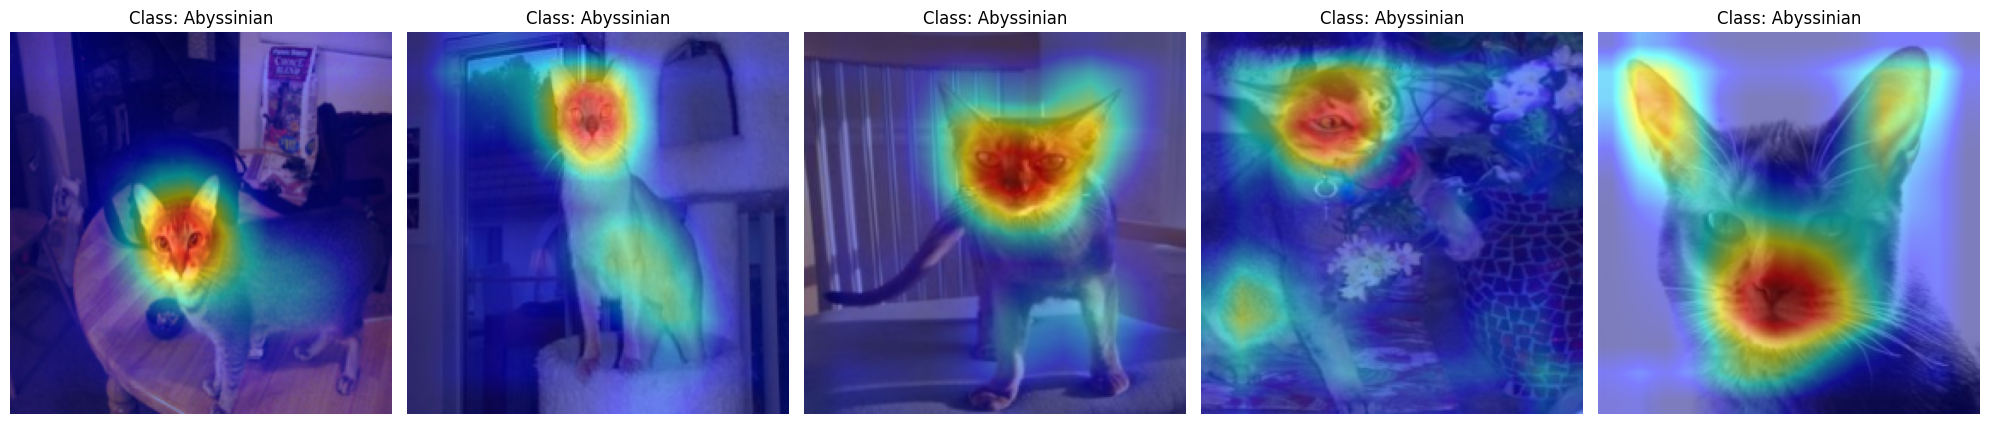

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget as ClassifierTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

best_model.eval()
for param in best_model.parameters():
    param.requires_grad = True

target_layers = []
if "ResNet" in str(type(best_model)):
    target_layers = [best_model.layer4[-1]]
elif "VGG" in str(type(best_model)):
    for layer in reversed(best_model.features):
        if isinstance(layer, nn.Conv2d):
            target_layers = [layer]
            break

print(f"Выбран слой для визуализации: {target_layers[0]}")

cam = GradCAM(model=best_model, target_layers=target_layers)

plt.figure(figsize=(20, 10))
for i in range(5):
    img_tensor, label = test_data[i]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    targets = [ClassifierTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)
    visualization = show_cam_on_image(img_show, grayscale_cam, use_rgb=True)

    plt.subplot(1, 5, i+1)
    plt.imshow(visualization)
    plt.title(f"Class: {test_data.classes[label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
